In [ ]:
# Загрузка данных из файла

In [2]:
import pandas as pd
from pathlib import Path
from typing import Optional, Tuple, Union
import logging
import os

# Настройка логирования
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class DataLoader:
    """
    Класс для загрузки данных о продажах снега из CSV файла.
    """

    def __init__(self, file_path: Optional[Union[str, Path]] = None):
        """
        Инициализация загрузчика данных.

        Args:
            file_path: Путь к CSV файлу. Если не указан, используется путь по умолчанию.
        """
        if file_path:
            self.file_path = Path(file_path)
        else:
            # В Jupyter notebook используем текущую рабочую директорию
            self.file_path = Path.cwd() / "DatasetSnowSales2.csv"

        self.data: Optional[pd.DataFrame] = None

    def load_data(self, delimiter: str = ';') -> Optional[pd.DataFrame]:
        """
        Загрузка данных из CSV файла.

        Args:
            delimiter: Разделитель полей в CSV (по умолчанию ';')

        Returns:
            DataFrame с загруженными данными или None в случае ошибки
        """
        try:
            # Проверка существования файла
            if not self.file_path.exists():
                logger.error(f"Файл не найден: {self.file_path}")
                logger.info(f"Текущая рабочая директория: {Path.cwd()}")

                # Поиск файла в текущей директории
                possible_files = list(Path.cwd().glob("*.csv"))
                if possible_files:
                    logger.info(f"Найденные CSV файлы в текущей директории: {[f.name for f in possible_files]}")
                return None

            logger.info(f"Загрузка данных из файла: {self.file_path}")

            # Загрузка CSV с правильной обработкой пропущенных значений
            self.data = pd.read_csv(
                self.file_path,
                delimiter=delimiter,
                encoding='utf-8',
                na_values=['', 'NA', 'NULL'],  # Указание значений, которые считать NaN
                keep_default_na=True
            )

            # Базовая очистка данных
            self._clean_data()

            # Вывод информации о загруженных данных
            logger.info(f"Данные успешно загружены. Размер: {self.data.shape}")
            logger.info(f"Колонки: {list(self.data.columns)}")

            return self.data

        except pd.errors.EmptyDataError:
            logger.error("Файл пуст")
            return None
        except pd.errors.ParserError as e:
            logger.error(f"Ошибка парсинга CSV: {e}")
            return None
        except Exception as e:
            logger.error(f"Неожиданная ошибка при загрузке данных: {e}")
            return None

    def _clean_data(self) -> None:
        """
        Внутренний метод для первичной очистки данных.
        """
        if self.data is None:
            return

        # Удаление пробелов из названий колонок
        self.data.columns = self.data.columns.str.strip()

        # Обработка пропущенных значений в числовых колонках
        numeric_columns = ['sales', 'tempday', 'tempnight']
        for col in numeric_columns:
            if col in self.data.columns:
                # Преобразование в числовой тип, ошибки преобразования станут NaN
                self.data[col] = pd.to_numeric(self.data[col], errors='coerce')

        # Преобразование даты
        if 'Date' in self.data.columns:
            try:
                self.data['Date'] = pd.to_datetime(self.data['Date'], format='%d.%m.%Y', errors='coerce')
            except Exception as e:
                logger.warning(f"Не удалось преобразовать даты: {e}")

        # Стандартизация типов осадков (приведение к нижнему регистру)
        if 'precipitation' in self.data.columns:
            self.data['precipitation'] = self.data['precipitation'].str.lower()

    def get_summary_stats(self) -> dict:
        """
        Получение базовой статистики по данным.

        Returns:
            Словарь со статистикой или пустой словарь, если данные не загружены
        """
        if self.data is None:
            logger.warning("Данные не загружены. Сначала вызовите load_data()")
            return {}

        stats = {
            'total_rows': len(self.data),
            'columns': list(self.data.columns),
            'missing_values': self.data.isnull().sum().to_dict(),
            'data_types': self.data.dtypes.astype(str).to_dict()
        }

        # Статистика по числовым колонкам
        numeric_cols = self.data.select_dtypes(include=['number']).columns
        if len(numeric_cols) > 0:
            stats['numeric_stats'] = self.data[numeric_cols].describe().to_dict()

        return stats

    def get_data(self) -> Optional[pd.DataFrame]:
        """
        Получение загруженных данных.

        Returns:
            DataFrame с данными или None, если данные не загружены
        """
        if self.data is None:
            logger.warning("Данные не загружены. Сначала вызовите load_data()")
        return self.data


# Пример использования модуля в Jupyter Notebook
if __name__ == "__main__":
    # Создание экземпляра загрузчика
    loader = DataLoader()

    # Загрузка данных
    df = loader.load_data()

    if df is not None:
        print("\nПервые 5 строк данных:")
        print(df.head())

        print("\nИнформация о данных:")
        print(df.info())

        print("\nБазовая статистика:")
        stats = loader.get_summary_stats()
        print(f"Всего строк: {stats.get('total_rows')}")
        print(f"Колонки: {stats.get('columns')}")

        # Проверка пропущенных значений
        if 'missing_values' in stats:
            missing = stats['missing_values']
            if any(missing.values()):
                print("\nПропущенные значения:")
                for col, count in missing.items():
                    if count > 0:
                        print(f"  {col}: {count}")
    else:
        print("Не удалось загрузить данные. Проверьте путь к файлу.")

        # Дополнительная информация для отладки
        print(f"\nТекущая рабочая директория: {Path.cwd()}")
        print("Файлы в текущей директории:")
        for f in Path.cwd().iterdir():
            if f.is_file():
                print(f"  {f.name}")

2026-02-24 22:00:33,458 - INFO - Загрузка данных из файла: C:\Users\User\PycharmProjects\PythonProject\DatasetSnowSales\DatasetSnowSales2.csv
2026-02-24 22:00:33,479 - INFO - Данные успешно загружены. Размер: (74, 6)
2026-02-24 22:00:33,481 - INFO - Колонки: ['Date', 'dayweek', 'sales', 'tempday', 'tempnight', 'precipitation']



Первые 5 строк данных:
        Date  dayweek  sales  tempday  tempnight precipitation
0 2025-12-01        1  143.0        2          0         cloud
1 2025-12-02        2  152.0        3          0         cloud
2 2025-12-03        3  148.0        4          0         cloud
3 2025-12-04        4   97.0        6          4          rain
4 2025-12-05        5  166.0        7          5         cloud

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           74 non-null     datetime64[ns]
 1   dayweek        74 non-null     int64         
 2   sales          73 non-null     float64       
 3   tempday        74 non-null     int64         
 4   tempnight      74 non-null     int64         
 5   precipitation  74 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory 

In [ ]:
# Проверка и обработка данных

In [3]:
import pandas as pd
import os

# Путь к файлу (измените при необходимости)
FILE_PATH = r"datasetSnowsales2.csv"


def check_missing_values():
    """
    Подсчитывает количество пропущенных значений в каждом столбце файла

    Returns:
    tuple: (DataFrame с данными, Series с количеством пропусков)
    """
    try:
        # Проверяем существование файла
        if not os.path.exists(FILE_PATH):
            raise FileNotFoundError(f"Файл {FILE_PATH} не найден")

        # Загружаем данные
        df = pd.read_csv(FILE_PATH, delimiter=';')

        # Подсчет пропущенных значений
        missing = df.isnull().sum()
        missing_percent = (missing / len(df)) * 100

        # Создаем сводную таблицу
        missing_df = pd.DataFrame({
            'Кол-во пропусков': missing,
            'Процент': missing_percent
        })

        return df, missing_df

    except Exception as e:
        print(f"Ошибка при чтении файла: {e}")
        return None, None


def generate_missing_report():
    """
    Генерирует подробный отчет о пропущенных значениях
    Выводит статистику для столбцов с пропусками
    """
    df, missing_df = check_missing_values()

    if df is None:
        return

    print("=" * 70)
    print("ОТЧЕТ О ПРОПУЩЕННЫХ ЗНАЧЕНИЯХ")
    print("=" * 70)

    # Фильтруем только столбцы с пропусками
    cols_with_missing = missing_df[missing_df['Кол-во пропусков'] > 0]

    if cols_with_missing.empty:
        print("Пропущенные значения не найдены.")
        return

    print(f"Всего записей: {len(df)}")
    print(f"Столбцы с пропусками: {len(cols_with_missing)}\n")

    # Для каждого столбца с пропусками выводим статистику
    for col in cols_with_missing.index:
        print(f"\n{'-' * 50}")
        print(f"СТОЛБЕЦ: '{col}'")
        print(f"{'-' * 50}")

        missing_count = cols_with_missing.loc[col, 'Кол-во пропусков']
        missing_percent = cols_with_missing.loc[col, 'Процент']
        print(f"Пропущено значений: {missing_count} ({missing_percent:.2f}%)")

        # Получаем данные без пропусков
        non_missing = df[col].dropna()

        if len(non_missing) > 0:
            # Определяем тип данных
            if pd.api.types.is_numeric_dtype(non_missing):
                # Для числовых данных
                print(f"\nСтатистика по имеющимся данным:")
                print(f"  Среднее: {non_missing.mean():.2f}")
                print(f"  Медиана: {non_missing.median():.2f}")
                print(f"  Минимум: {non_missing.min()}")
                print(f"  Максимум: {non_missing.max()}")

                # Наиболее частые значения (топ-3)
                value_counts = non_missing.value_counts().head(3)
                print(f"  Наиболее частые значения:")
                for val, count in value_counts.items():
                    print(f"    {val}: {count} раз ({count / len(non_missing) * 100:.1f}%)")

            else:
                # Для текстовых/категориальных данных
                print(f"\nСтатистика по имеющимся данным:")

                # Наиболее частые значения
                value_counts = non_missing.value_counts().head(5)
                print(f"  Наиболее частые значения:")
                for val, count in value_counts.items():
                    print(f"    '{val}': {count} раз ({count / len(non_missing) * 100:.1f}%)")

                # Уникальные значения
                print(f"  Уникальных значений: {non_missing.nunique()}")

        else:
            print("  Нет данных для анализа (все значения пропущены)")

    print("\n" + "=" * 70)
    print("РЕКОМЕНДАЦИИ ПО ЗАПОЛНЕНИЮ")
    print("=" * 70)
    print("Для заполнения пропусков можно использовать:")
    print("- Числовые данные: среднее, медиана")
    print("- Категориальные данные: наиболее частое значение (мода)")
    print("- Временные ряды: интерполяция или предыдущее значение")


def main():
    """Основная функция для запуска анализа"""
    generate_missing_report()


if __name__ == "__main__":
    main()

ОТЧЕТ О ПРОПУЩЕННЫХ ЗНАЧЕНИЯХ
Всего записей: 74
Столбцы с пропусками: 1


--------------------------------------------------
СТОЛБЕЦ: 'sales'
--------------------------------------------------
Пропущено значений: 1 (1.35%)

Статистика по имеющимся данным:
  Среднее: 323.00
  Медиана: 342.00
  Минимум: 97.0
  Максимум: 696.0
  Наиболее частые значения:
    337.0: 2 раз (2.7%)
    263.0: 2 раз (2.7%)
    226.0: 2 раз (2.7%)

РЕКОМЕНДАЦИИ ПО ЗАПОЛНЕНИЮ
Для заполнения пропусков можно использовать:
- Числовые данные: среднее, медиана
- Категориальные данные: наиболее частое значение (мода)
- Временные ряды: интерполяция или предыдущее значение


In [ ]:
# визуализация данных

Пропущенные значения в sales: 1
Пропуск заполнен медианным значением для дня 4: 286
Данные загружены: 74 строк, 10 колонок
Период: с 2025-12-01 по 2026-02-12
Диапазон продаж: 97 - 696

Базовая статистика:
       sales  tempday  tempnight
count   74.0     74.0       74.0
mean   322.5     -3.2       -9.4
std    132.6      6.0        8.8
min     97.0    -14.0      -29.0
25%    202.2     -8.8      -16.8
50%    339.5     -2.5       -8.0
75%    416.2      1.0       -2.0
max    696.0      9.0        6.0

АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

Гистограммы:


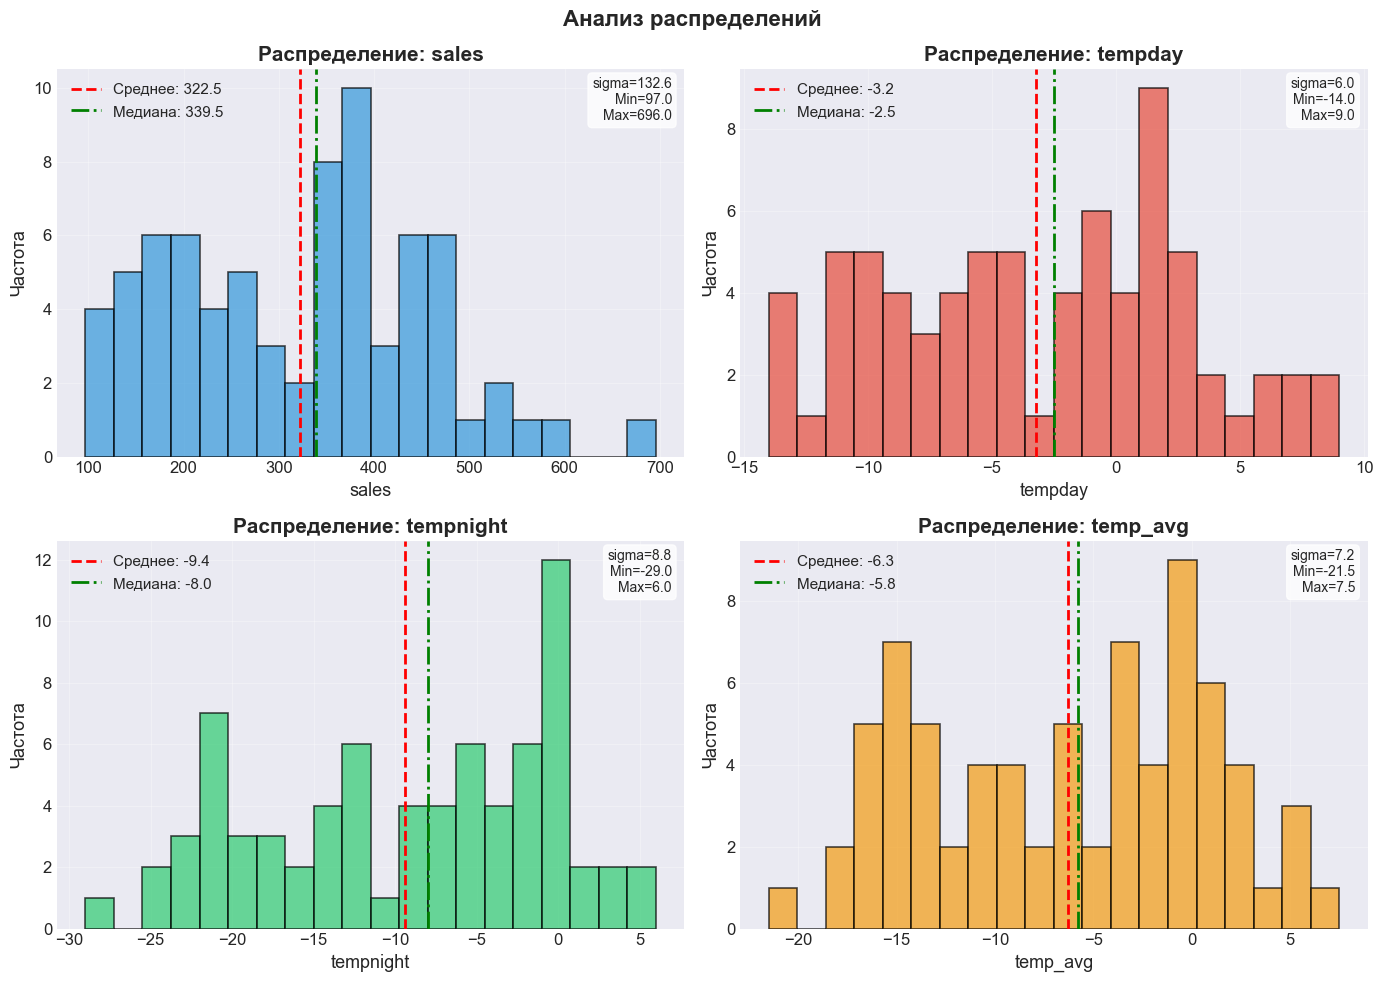


АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

Линейные графики:


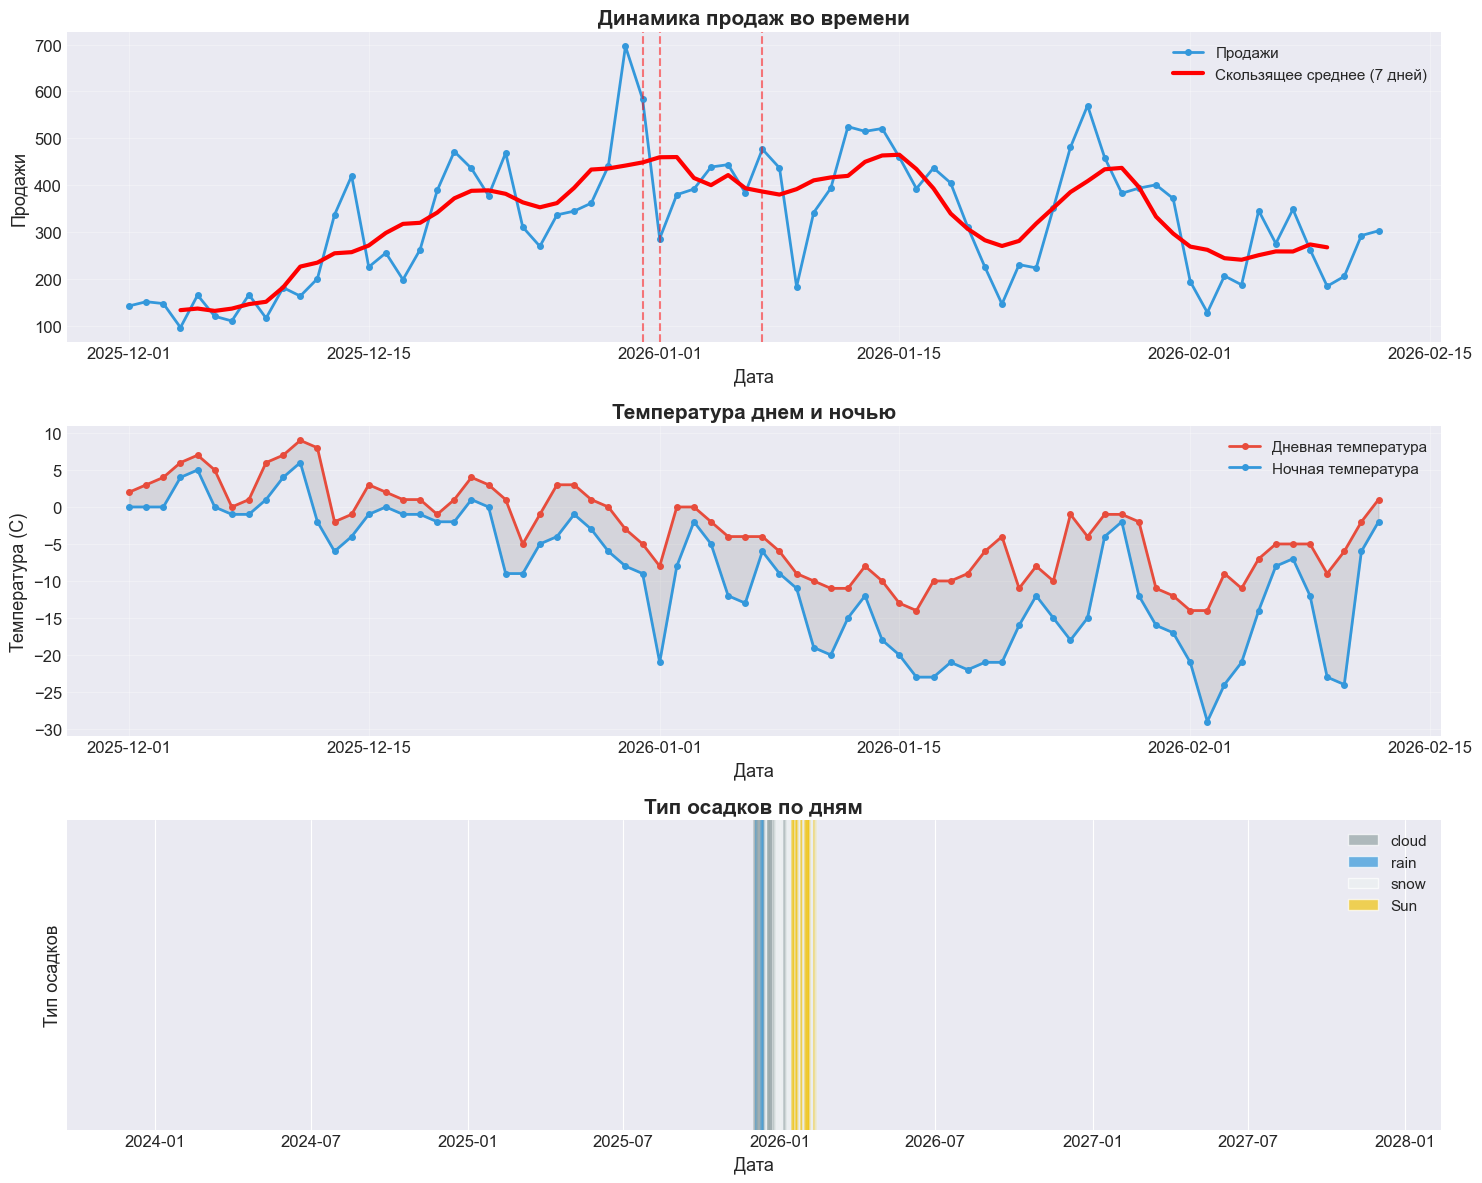


АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

Диаграммы рассеяния:
1. Продажи vs Дневная температура
2. Продажи vs Ночная температура
3. Продажи vs Средняя температура


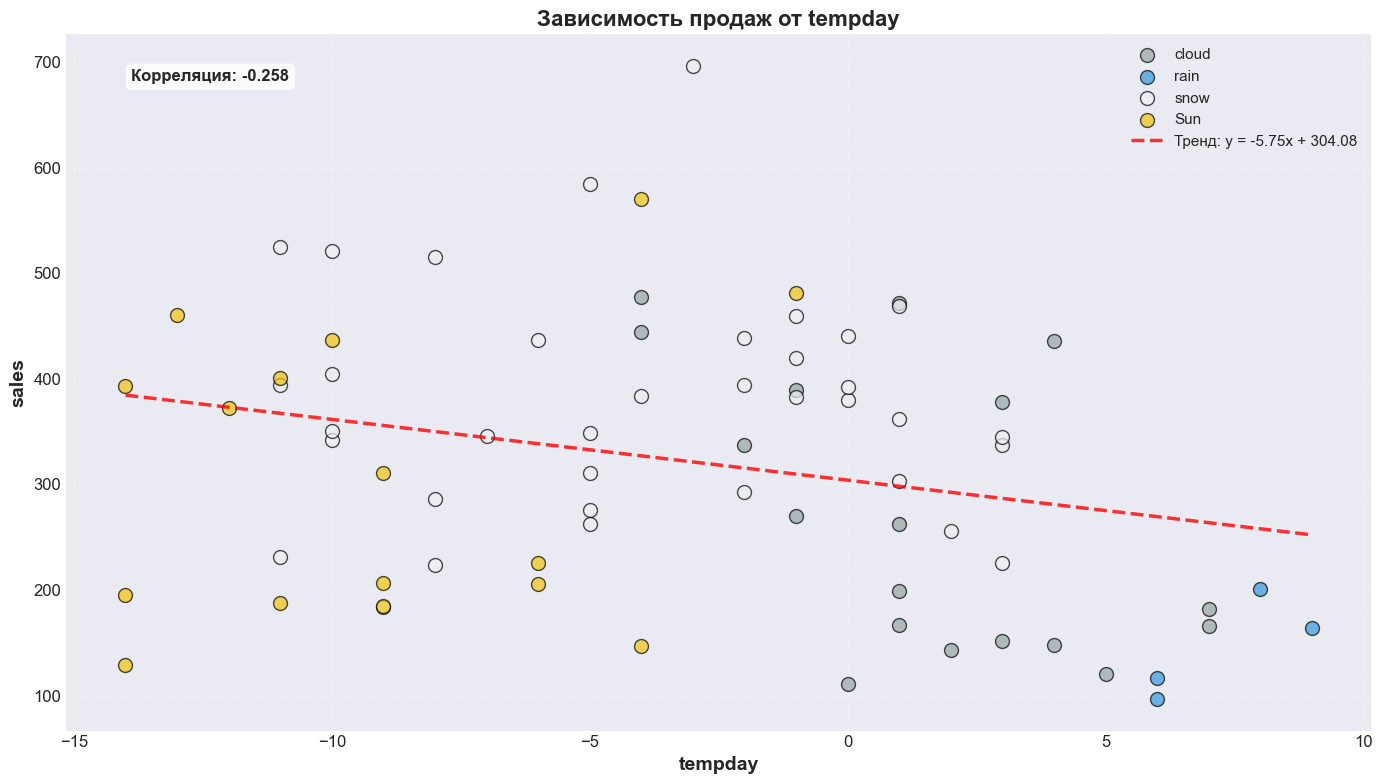


АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

Диаграммы рассеяния:
1. Продажи vs Дневная температура
2. Продажи vs Ночная температура
3. Продажи vs Средняя температура


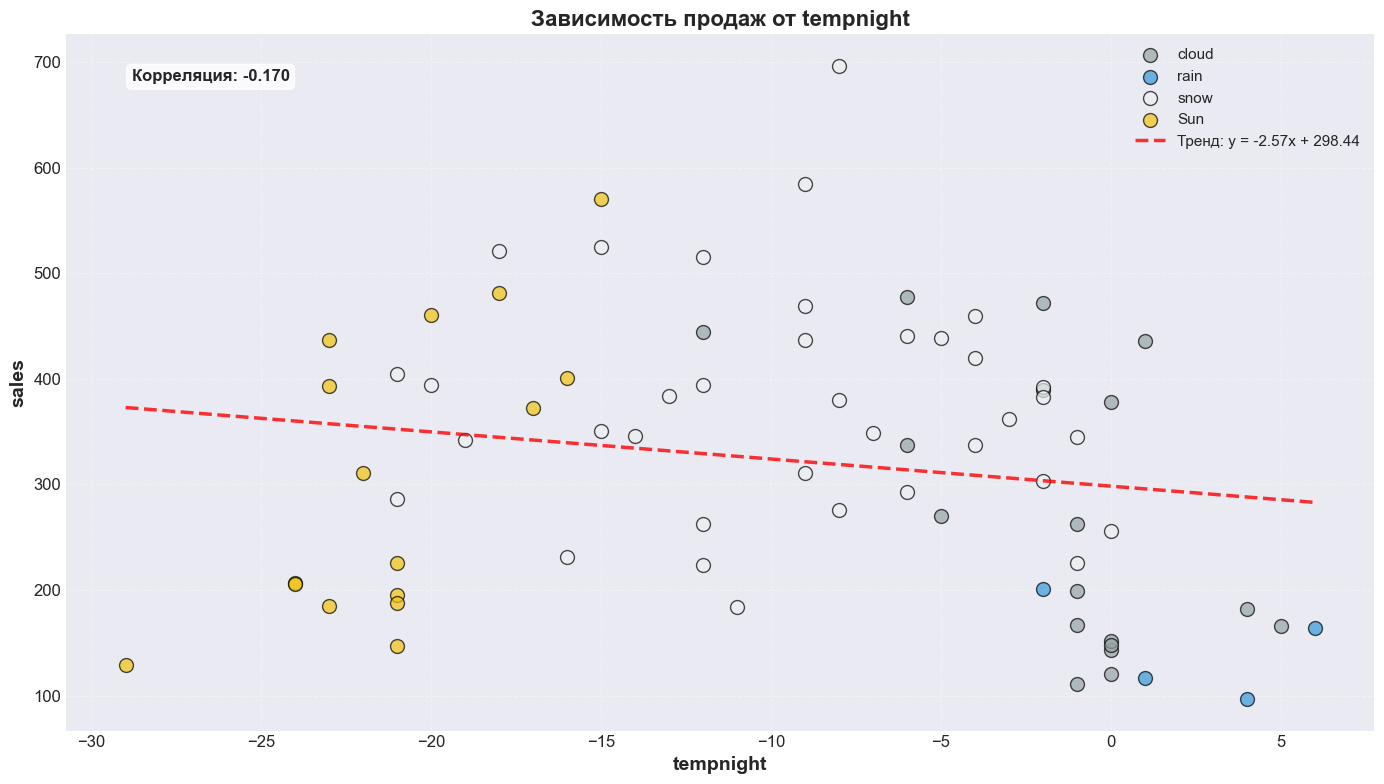


АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

Диаграммы рассеяния:
1. Продажи vs Дневная температура
2. Продажи vs Ночная температура
3. Продажи vs Средняя температура


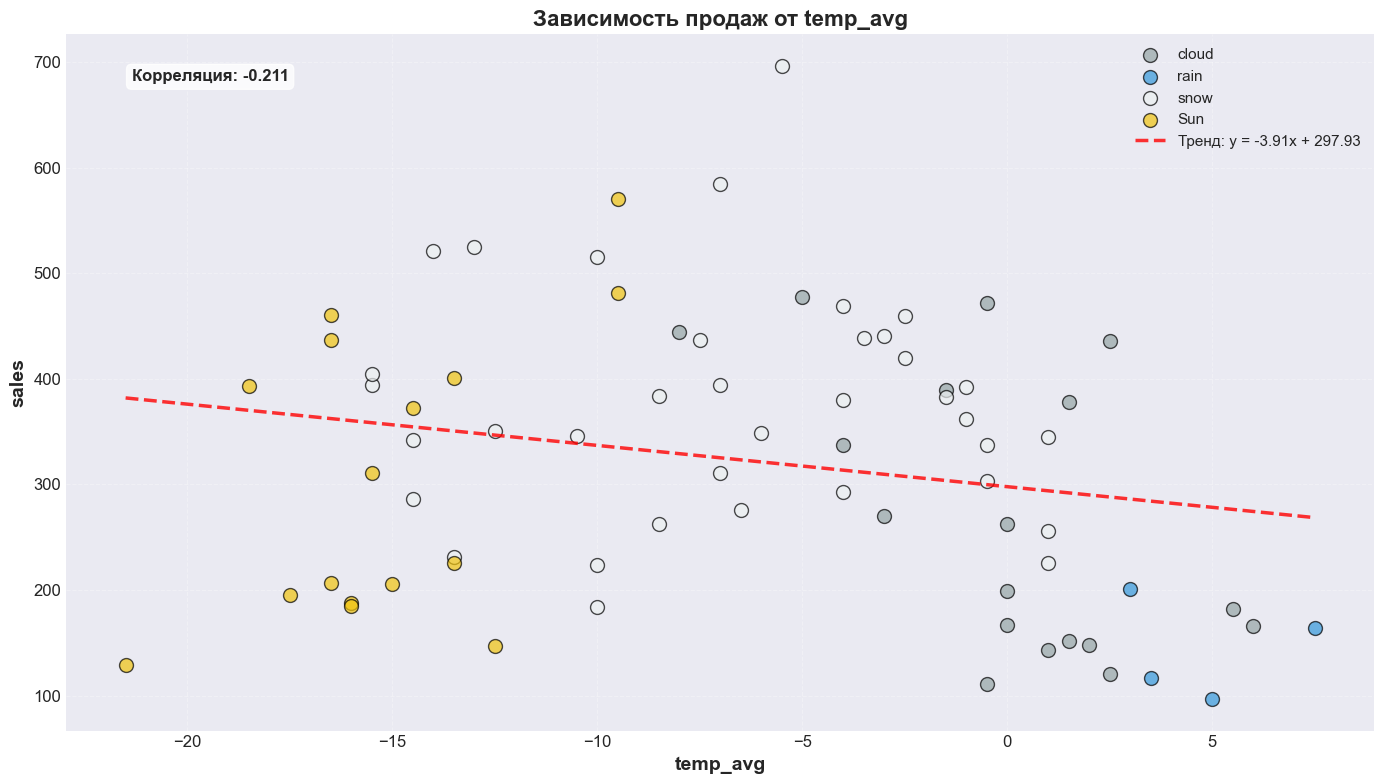


АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

Анализ по дням недели:


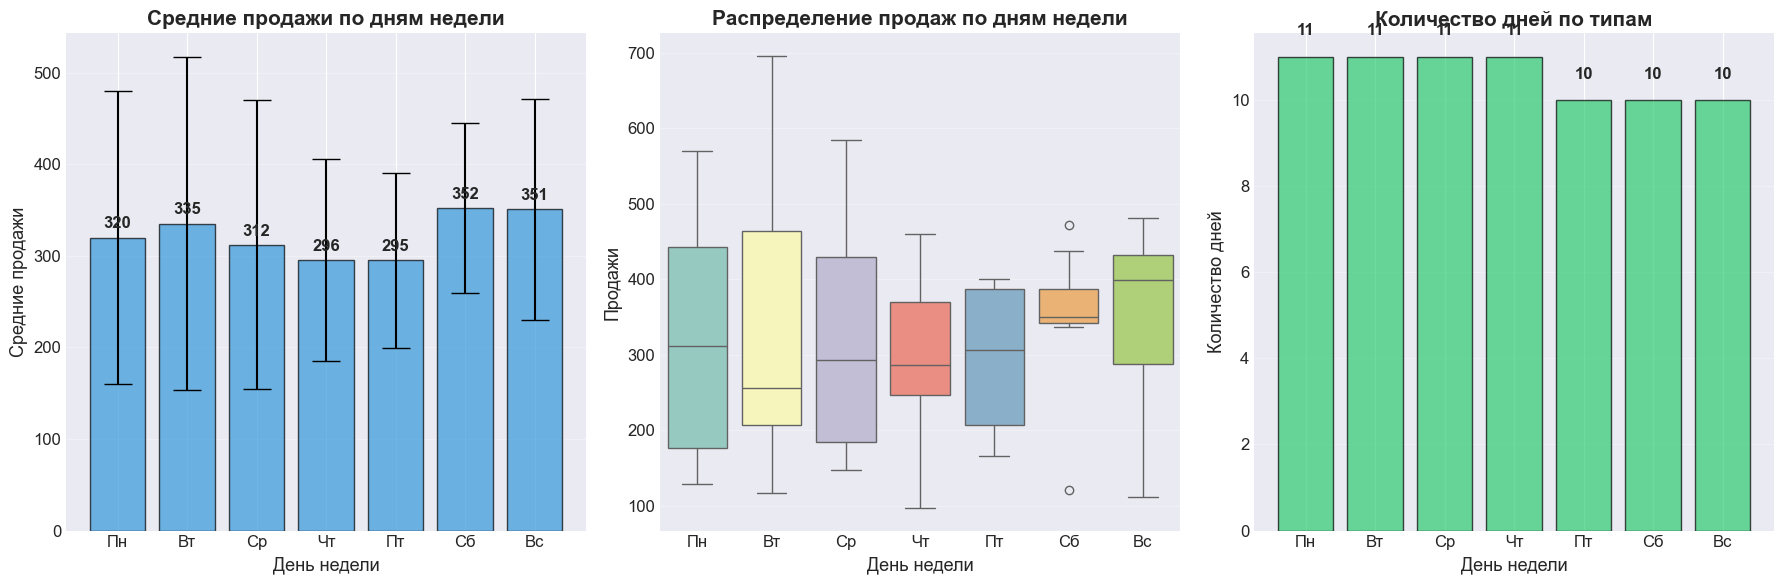


АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

Погодный анализ:


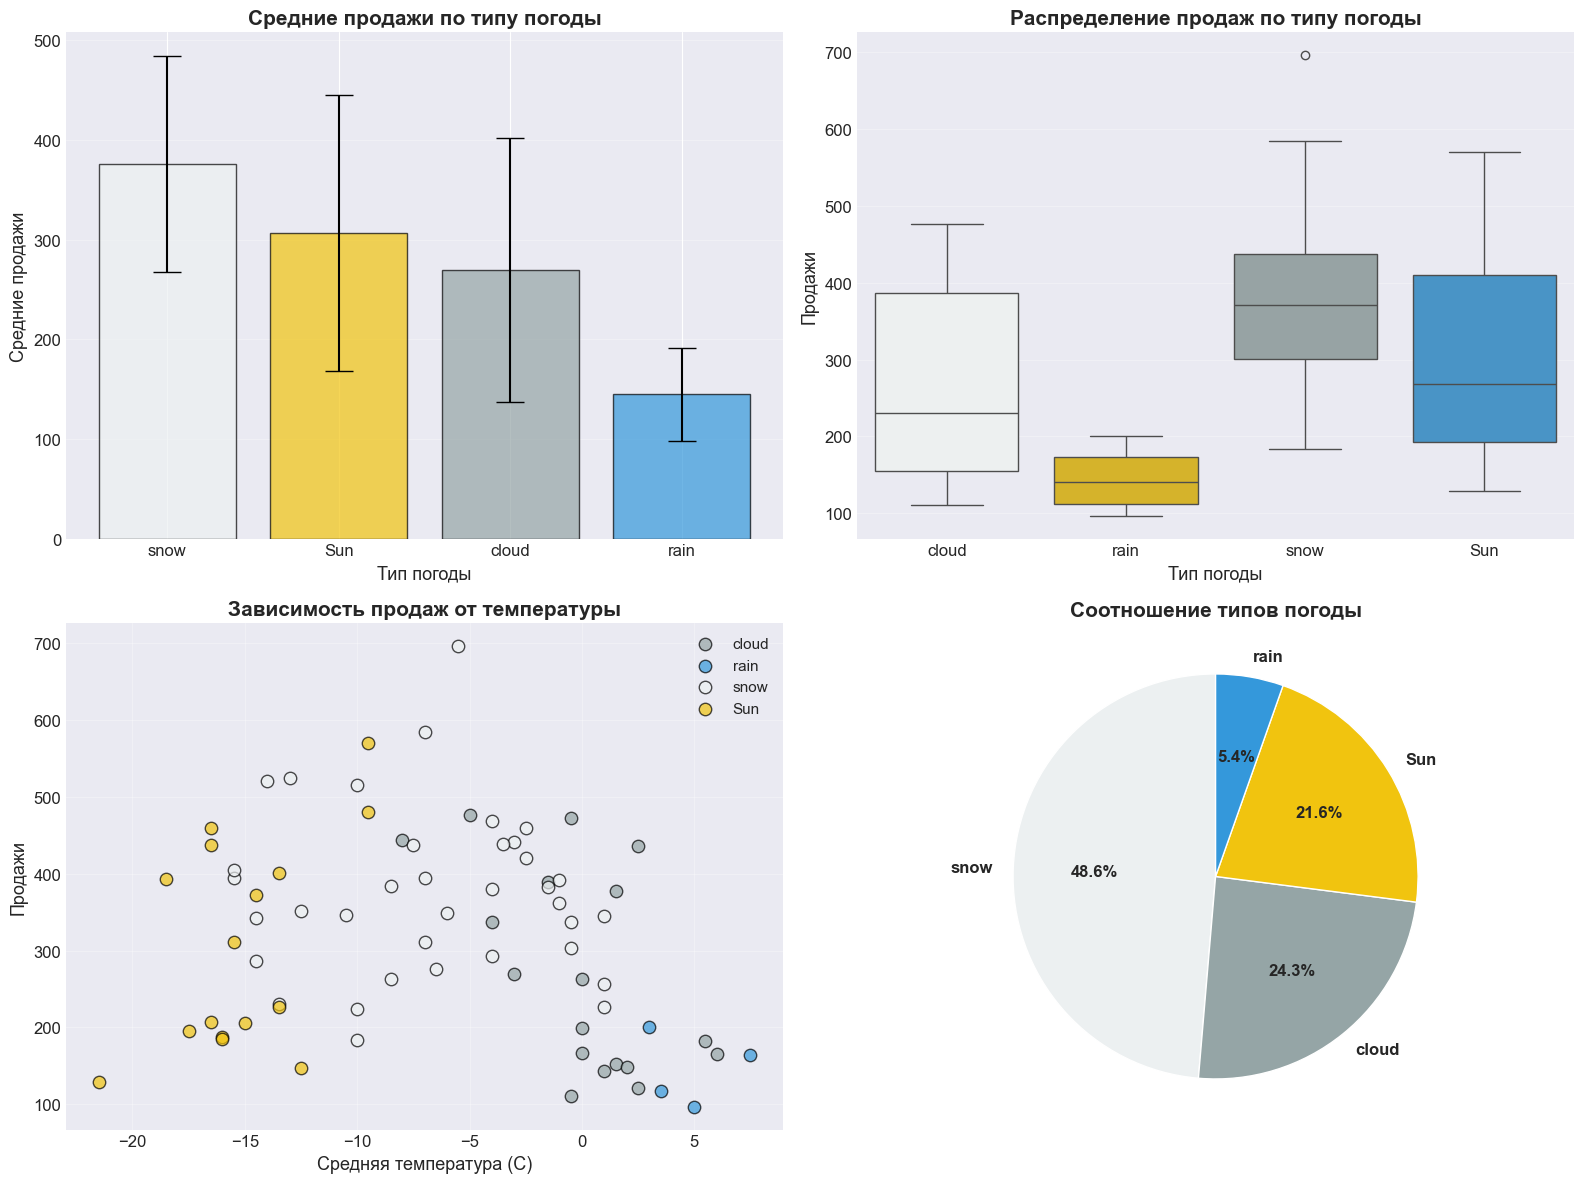


АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД

Доступные визуализации:
1. Гистограммы (распределения sales, temperature)
2. Линейные графики (временные ряды)
3. Диаграммы рассеяния (зависимость от температуры)
4. Анализ по дням недели
5. Погодный анализ
0. Выход

До свидания!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Optional, List, Union, Tuple, Dict
import warnings

warnings.filterwarnings('ignore')

# Настройка стилей для профессиональных графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['legend.fontsize'] = 11


class SnowSalesVisualizer:
    """
    Класс для визуализации данных о продажах в зимний период
    """

    def __init__(self, file_path: str = 'DatasetSnowSales2.csv'):
        """
        Инициализация с загрузкой данных
        """
        self.file_path = file_path
        self.df = None
        self.weather_colors = {
            'cloud': '#95a5a6',  # серый
            'rain': '#3498db',  # синий
            'snow': '#ecf0f1',  # белый/светло-серый
            'Sun': '#f1c40f'  # желтый
        }
        self.load_data()

    def load_data(self):
        """Загрузка и предобработка данных"""
        if not Path(self.file_path).exists():
            print(f"Файл не найден: {self.file_path}")
            return False

        try:
            # Загрузка с правильным разделителем (;)
            self.df = pd.read_csv(self.file_path, delimiter=';', encoding='utf-8')

            # Преобразование даты
            self.df['Date'] = pd.to_datetime(self.df['Date'], format='%d.%m.%Y', errors='coerce')

            # Проверка на ошибки в датах
            if self.df['Date'].isnull().any():
                print(f"Обнаружены ошибки в датах. Проверьте формат.")
                self.df = self.df.dropna(subset=['Date'])

            # Обработка пропущенных значений в sales
            missing_sales = self.df['sales'].isnull().sum()
            print(f"Пропущенные значения в sales: {missing_sales}")

            if missing_sales > 0:
                # Заполним пропуск медианным значением для этого дня недели
                missing_indices = self.df[self.df['sales'].isnull()].index
                for idx in missing_indices:
                    missing_dayweek = self.df.loc[idx, 'dayweek']
                    median_sales = self.df[self.df['dayweek'] == missing_dayweek]['sales'].median()
                    self.df.loc[idx, 'sales'] = median_sales
                    print(f"Пропуск заполнен медианным значением для дня {missing_dayweek}: {median_sales:.0f}")

            # Преобразование типов
            self.df['sales'] = pd.to_numeric(self.df['sales'], errors='coerce')
            self.df['tempday'] = pd.to_numeric(self.df['tempday'], errors='coerce')
            self.df['tempnight'] = pd.to_numeric(self.df['tempnight'], errors='coerce')
            self.df['dayweek'] = pd.to_numeric(self.df['dayweek'], errors='coerce')

            # Добавим полезные колонки
            self.df['month'] = self.df['Date'].dt.month
            self.df['day'] = self.df['Date'].dt.day
            self.df['week'] = self.df['Date'].dt.isocalendar().week
            self.df['temp_avg'] = (self.df['tempday'] + self.df['tempnight']) / 2

            print(f"Данные загружены: {self.df.shape[0]} строк, {self.df.shape[1]} колонок")
            print(f"Период: с {self.df['Date'].min().date()} по {self.df['Date'].max().date()}")
            print(f"Диапазон продаж: {self.df['sales'].min():.0f} - {self.df['sales'].max():.0f}")

            return True

        except Exception as e:
            print(f"Ошибка загрузки: {e}")
            return False

    # =========================================================================
    # 1. ГИСТОГРАММЫ
    # =========================================================================

    def plot_histograms(self, columns: List[str] = None, save_path: Optional[str] = None):
        """
        Построение гистограмм для анализа распределений
        """
        if self.df is None:
            print("Данные не загружены")
            return

        if columns is None:
            columns = ['sales', 'tempday', 'tempnight', 'temp_avg']

        # Фильтруем только существующие колонки
        columns = [col for col in columns if col in self.df.columns]

        if not columns:
            print("Нет доступных колонок для визуализации")
            return

        # Создаем сетку графиков
        n_cols = min(2, len(columns))
        n_rows = (len(columns) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
        if n_rows == 1 and n_cols == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

        for idx, (col, color) in enumerate(zip(columns, colors)):
            ax = axes[idx]
            data = self.df[col].dropna()

            if len(data) == 0:
                ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax.transAxes)
                continue

            # Гистограмма
            n, bins, patches = ax.hist(data, bins=20, density=False,
                                       alpha=0.7, color=color, edgecolor='black',
                                       linewidth=1.2)

            # Статистика
            mean_val = data.mean()
            median_val = data.median()
            std_val = data.std()

            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                       label=f'Среднее: {mean_val:.1f}')
            ax.axvline(median_val, color='green', linestyle='-.', linewidth=2,
                       label=f'Медиана: {median_val:.1f}')

            # Метрики
            stats_text = f'sigma={std_val:.1f}\nMin={data.min():.1f}\nMax={data.max():.1f}'
            ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
                    ha='right', va='top', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

            ax.set_title(f'Распределение: {col}', fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Частота')
            ax.legend(loc='upper left')
            ax.grid(True, alpha=0.3)

        # Скрываем лишние графики
        for idx in range(len(columns), len(axes)):
            axes[idx].set_visible(False)

        plt.suptitle('Анализ распределений', fontsize=16, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"График сохранен: {save_path}")

        plt.show()

    # =========================================================================
    # 2. ЛИНЕЙНЫЕ ГРАФИКИ
    # =========================================================================

    def plot_time_series(self, save_path: Optional[str] = None):
        """
        Линейные графики временных рядов
        """
        if self.df is None:
            print("Данные не загружены")
            return

        fig, axes = plt.subplots(3, 1, figsize=(15, 12))

        # 1. Продажи по времени
        ax1 = axes[0]
        ax1.plot(self.df['Date'], self.df['sales'], 'o-', color='#3498db',
                 linewidth=2, markersize=4, label='Продажи')

        # Добавляем скользящее среднее
        if len(self.df) >= 7:
            rolling_mean = self.df['sales'].rolling(window=7, center=True).mean()
            ax1.plot(self.df['Date'], rolling_mean, 'r-', linewidth=3,
                     label='Скользящее среднее (7 дней)')

        # Отмечаем праздники
        holidays = ['2025-12-31', '2026-01-01', '2026-01-07']
        for holiday in holidays:
            ax1.axvline(pd.to_datetime(holiday), color='red', linestyle='--', alpha=0.5)

        ax1.set_title('Динамика продаж во времени', fontweight='bold')
        ax1.set_xlabel('Дата')
        ax1.set_ylabel('Продажи')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Температура днем и ночью
        ax2 = axes[1]
        ax2.plot(self.df['Date'], self.df['tempday'], 'o-', color='#e74c3c',
                 linewidth=2, markersize=4, label='Дневная температура')
        ax2.plot(self.df['Date'], self.df['tempnight'], 'o-', color='#3498db',
                 linewidth=2, markersize=4, label='Ночная температура')
        ax2.fill_between(self.df['Date'], self.df['tempnight'], self.df['tempday'],
                         alpha=0.2, color='gray')
        ax2.set_title('Температура днем и ночью', fontweight='bold')
        ax2.set_xlabel('Дата')
        ax2.set_ylabel('Температура (C)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Осадки по дням
        ax3 = axes[2]
        weather_counts = self.df.groupby('Date')['precipitation'].first()
        colors = [self.weather_colors.get(w, '#95a5a6') for w in weather_counts.values]

        for date, weather in weather_counts.items():
            color = self.weather_colors.get(weather, '#95a5a6')
            ax3.axvline(date, color=color, alpha=0.5, linewidth=2)

        ax3.set_title('Тип осадков по дням', fontweight='bold')
        ax3.set_xlabel('Дата')
        ax3.set_ylabel('Тип осадков')
        ax3.set_yticks([])

        # Легенда для погоды
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, label=weather, alpha=0.7)
                           for weather, color in self.weather_colors.items()]
        ax3.legend(handles=legend_elements, loc='upper right')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"График сохранен: {save_path}")

        plt.show()

    # =========================================================================
    # 3. ДИАГРАММЫ РАССЕЯНИЯ
    # =========================================================================

    def plot_scatter(self, x_col: str = 'tempday', y_col: str = 'sales',
                     color_by: str = 'precipitation', save_path: Optional[str] = None):
        """
        Диаграмма рассеяния с цветовым кодированием по погоде
        """
        if self.df is None:
            print("Данные не загружены")
            return

        if x_col not in self.df.columns or y_col not in self.df.columns:
            print(f"Колонки {x_col} или {y_col} не найдены")
            return

        fig, ax = plt.subplots(figsize=(14, 8))

        # Создаем scatter plot с цветами по погоде
        unique_weather = self.df['precipitation'].dropna().unique()
        for weather in unique_weather:
            mask = self.df['precipitation'] == weather
            color = self.weather_colors.get(weather, '#95a5a6')

            ax.scatter(self.df.loc[mask, x_col], self.df.loc[mask, y_col],
                       c=color, label=weather, s=100, alpha=0.7,
                       edgecolors='black', linewidth=1)

        # Добавляем линию тренда
        clean_data = self.df[[x_col, y_col]].dropna()
        if len(clean_data) > 1:
            z = np.polyfit(clean_data[x_col], clean_data[y_col], 1)
            p = np.poly1d(z)
            x_line = np.linspace(clean_data[x_col].min(), clean_data[x_col].max(), 100)
            ax.plot(x_line, p(x_line), "r--", linewidth=2.5, alpha=0.8,
                    label=f'Тренд: y = {z[0]:.2f}x + {z[1]:.2f}')

            # Корреляция
            corr = clean_data[x_col].corr(clean_data[y_col])
            ax.text(0.05, 0.95, f'Корреляция: {corr:.3f}', transform=ax.transAxes,
                    fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    verticalalignment='top', fontweight='bold')

        ax.set_xlabel(x_col, fontsize=14, fontweight='bold')
        ax.set_ylabel(y_col, fontsize=14, fontweight='bold')
        ax.set_title(f'Зависимость продаж от {x_col}', fontsize=16, fontweight='bold')
        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3, linestyle='--')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"График сохранен: {save_path}")

        plt.show()

    # =========================================================================
    # 4. ДИАГРАММА ПО ДНЯМ НЕДЕЛИ
    # =========================================================================

    def plot_weekday_analysis(self, save_path: Optional[str] = None):
        """
        Анализ продаж по дням недели
        """
        if self.df is None:
            print("Данные не загружены")
            return

        # Словарь для дней недели
        weekdays = {1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'}
        self.df['weekday_name'] = self.df['dayweek'].map(weekdays)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # 1. Средние продажи по дням недели
        ax1 = axes[0]
        weekday_sales = self.df.groupby('weekday_name')['sales'].agg(['mean', 'std']).reindex(
            ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])

        ax1.bar(weekday_sales.index, weekday_sales['mean'], yerr=weekday_sales['std'],
                capsize=10, color='#3498db', edgecolor='black', alpha=0.7)
        ax1.set_xlabel('День недели')
        ax1.set_ylabel('Средние продажи')
        ax1.set_title('Средние продажи по дням недели', fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='y')

        # Добавляем значения
        for i, (idx, row) in enumerate(weekday_sales.iterrows()):
            if not pd.isna(row['mean']):
                ax1.text(i, row['mean'] + 10, f'{row["mean"]:.0f}',
                         ha='center', fontweight='bold')

        # 2. Box plot продаж по дням недели
        ax2 = axes[1]
        df_weekday = self.df.dropna(subset=['weekday_name', 'sales']).copy()
        if not df_weekday.empty:
            df_weekday['weekday_name'] = pd.Categorical(df_weekday['weekday_name'],
                                                        categories=['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'],
                                                        ordered=True)

            sns.boxplot(data=df_weekday, x='weekday_name', y='sales', ax=ax2, palette='Set3')
            ax2.set_xlabel('День недели')
            ax2.set_ylabel('Продажи')
            ax2.set_title('Распределение продаж по дням недели', fontweight='bold')
            ax2.grid(True, alpha=0.3, axis='y')

        # 3. Количество наблюдений по дням недели
        ax3 = axes[2]
        day_counts = self.df['weekday_name'].value_counts().reindex(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])

        ax3.bar(day_counts.index, day_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
        ax3.set_xlabel('День недели')
        ax3.set_ylabel('Количество дней')
        ax3.set_title('Количество дней по типам', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')

        for i, (idx, val) in enumerate(day_counts.items()):
            if not pd.isna(val):
                ax3.text(i, val + 0.5, str(int(val)), ha='center', fontweight='bold')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"График сохранен: {save_path}")

        plt.show()

    # =========================================================================
    # 5. ПОГОДНЫЙ АНАЛИЗ
    # =========================================================================

    def plot_weather_analysis(self, save_path: Optional[str] = None):
        """
        Анализ влияния погоды на продажи
        """
        if self.df is None:
            print("Данные не загружены")
            return

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Средние продажи по типу погоды
        ax1 = axes[0, 0]
        weather_sales = self.df.groupby('precipitation')['sales'].agg(['mean', 'std']).sort_values('mean',
                                                                                                   ascending=False)

        colors = [self.weather_colors.get(w, '#95a5a6') for w in weather_sales.index]
        ax1.bar(weather_sales.index, weather_sales['mean'], yerr=weather_sales['std'],
                capsize=10, color=colors, edgecolor='black', alpha=0.7)
        ax1.set_xlabel('Тип погоды')
        ax1.set_ylabel('Средние продажи')
        ax1.set_title('Средние продажи по типу погоды', fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='y')

        # 2. Распределение продаж по погоде (box plot)
        ax2 = axes[0, 1]
        df_weather = self.df.dropna(subset=['precipitation', 'sales'])
        if not df_weather.empty:
            sns.boxplot(data=df_weather, x='precipitation', y='sales', ax=ax2, palette=colors)
            ax2.set_xlabel('Тип погоды')
            ax2.set_ylabel('Продажи')
            ax2.set_title('Распределение продаж по типу погоды', fontweight='bold')
            ax2.grid(True, alpha=0.3, axis='y')

        # 3. Зависимость продаж от температуры с учетом погоды
        ax3 = axes[1, 0]
        for weather in self.df['precipitation'].dropna().unique():
            mask = self.df['precipitation'] == weather
            color = self.weather_colors.get(weather, '#95a5a6')
            ax3.scatter(self.df.loc[mask, 'temp_avg'], self.df.loc[mask, 'sales'],
                        c=color, label=weather, s=80, alpha=0.7, edgecolors='black')

        ax3.set_xlabel('Средняя температура (C)')
        ax3.set_ylabel('Продажи')
        ax3.set_title('Зависимость продаж от температуры', fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. Количество дней по типам погоды
        ax4 = axes[1, 1]
        weather_counts = self.df['precipitation'].value_counts()
        if not weather_counts.empty:
            wedges, texts, autotexts = ax4.pie(weather_counts.values, labels=weather_counts.index,
                                               colors=[self.weather_colors.get(w, '#95a5a6') for w in weather_counts.index],
                                               autopct='%1.1f%%', startangle=90, textprops={'fontweight': 'bold'})
            ax4.set_title('Соотношение типов погоды', fontweight='bold')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"График сохранен: {save_path}")

        plt.show()

    # =========================================================================
    # ИНТЕРАКТИВНОЕ МЕНЮ
    # =========================================================================

    def interactive_menu(self):
        """
        Интерактивное меню для выбора визуализаций
        """
        if self.df is None:
            print("Данные не загружены")
            return

        while True:
            print("\n" + "=" * 60)
            print("АНАЛИЗ ДАННЫХ О ПРОДАЖАХ В ЗИМНИЙ ПЕРИОД")
            print("=" * 60)
            print("\nДоступные визуализации:")
            print("1. Гистограммы (распределения sales, temperature)")
            print("2. Линейные графики (временные ряды)")
            print("3. Диаграммы рассеяния (зависимость от температуры)")
            print("4. Анализ по дням недели")
            print("5. Погодный анализ")
            print("0. Выход")

            choice = input("\nВаш выбор (0-5): ").strip()

            if choice == '1':
                print("\nГистограммы:")
                self.plot_histograms()

            elif choice == '2':
                print("\nЛинейные графики:")
                self.plot_time_series()

            elif choice == '3':
                print("\nДиаграммы рассеяния:")
                print("1. Продажи vs Дневная температура")
                print("2. Продажи vs Ночная температура")
                print("3. Продажи vs Средняя температура")
                scatter_choice = input("Выберите тип (1-3): ").strip()

                if scatter_choice == '1':
                    self.plot_scatter(x_col='tempday', y_col='sales')
                elif scatter_choice == '2':
                    self.plot_scatter(x_col='tempnight', y_col='sales')
                elif scatter_choice == '3':
                    self.plot_scatter(x_col='temp_avg', y_col='sales')
                else:
                    print("Неверный выбор")

            elif choice == '4':
                print("\nАнализ по дням недели:")
                self.plot_weekday_analysis()

            elif choice == '5':
                print("\nПогодный анализ:")
                self.plot_weather_analysis()

            elif choice == '0':
                print("\nДо свидания!")
                break

            else:
                print("\nНеверный выбор. Пожалуйста, выберите 0-5.")


# =============================================================================
# ЗАПУСК
# =============================================================================

if __name__ == "__main__":
    # Создаем визуализатор и запускаем интерактивное меню
    viz = SnowSalesVisualizer('DatasetSnowSales2.csv')

    if viz.df is not None:
        # Показываем базовую статистику
        print("\nБазовая статистика:")
        print(viz.df[['sales', 'tempday', 'tempnight']].describe().round(1))

        # Запускаем интерактивное меню
        viz.interactive_menu()
    else:
        print("Не удалось загрузить данные. Проверьте файл.")